In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn import metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score,davies_bouldin_score

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

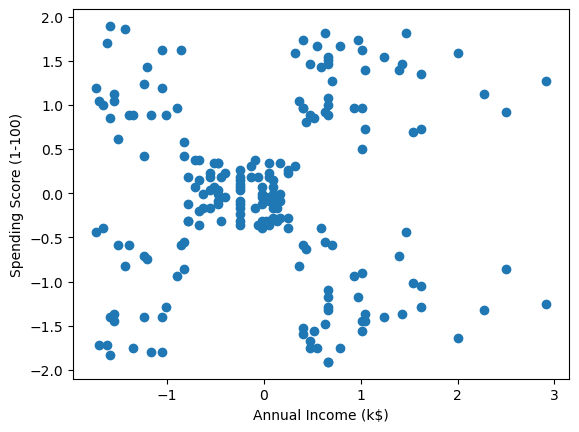

In [8]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0],X_scaled[:,1])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

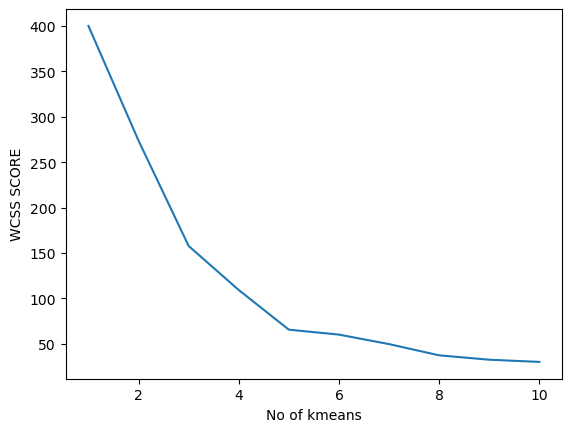

In [9]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(X_scaled)
    wcss.append(Kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.xlabel("No of kmeans")
plt.ylabel("WCSS SCORE")
plt.show()

## Kmeans

In [19]:
Kmeans =KMeans(n_clusters=5, random_state=42)
cluster = Kmeans.fit_predict(X_scaled)
df['cluster']=cluster

In [21]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


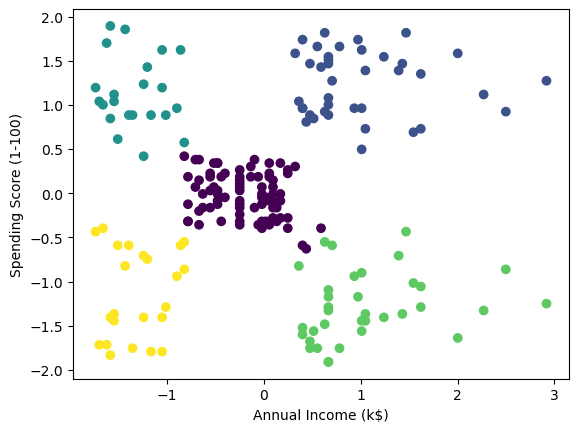

In [23]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=cluster)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [25]:
cluster

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1])

In [31]:
scores = []
values = np.arange(2, 10)

In [37]:
for num_clusters in values:
    kmeans = KMeans(init='k-means++', n_clusters=num_clusters, n_init=10)
    kmeans.fit(X)
    score = metrics.silhouette_score(X, kmeans.labels_, 
                metric='euclidean', sample_size=len(X))

    print("\nNumber of clusters =", num_clusters)
    print("Silhouette score =", score)
                    
    scores.append(score)


Number of clusters = 2
Silhouette score = 0.29689691625030085

Number of clusters = 3
Silhouette score = 0.4676135815877543

Number of clusters = 4
Silhouette score = 0.4931963109249047

Number of clusters = 5
Silhouette score = 0.553931997444648

Number of clusters = 6
Silhouette score = 0.5397610306343199

Number of clusters = 7
Silhouette score = 0.5288104473798049

Number of clusters = 8
Silhouette score = 0.45492755850983463

Number of clusters = 9
Silhouette score = 0.45912667975312715



Optimal number of clusters = 5


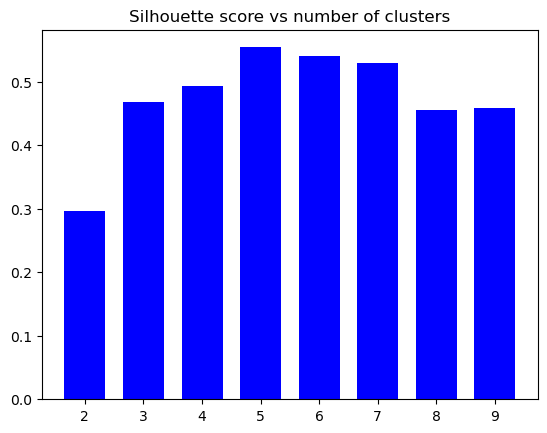

In [39]:
plt.figure()
plt.bar(values, scores, width=0.7, color='blue', align='center')
plt.title('Silhouette score vs number of clusters')

num_clusters = np.argmax(scores) + values[0]
print('\nOptimal number of clusters =', num_clusters)

plt.show()

In [43]:
sil=silhouette_score(X_scaled,cluster)
db=davies_bouldin_score(X_scaled,cluster)
ch=calinski_harabasz_score(X_scaled,cluster)

print("\nSilhouette Score:",sil)
print("Davies-Bouldin Score:",db)
print("Calinski-Harabasz Score:",ch)


Silhouette Score: 0.5546571631111091
Davies-Bouldin Score: 0.5722356162263352
Calinski-Harabasz Score: 248.64932001536357


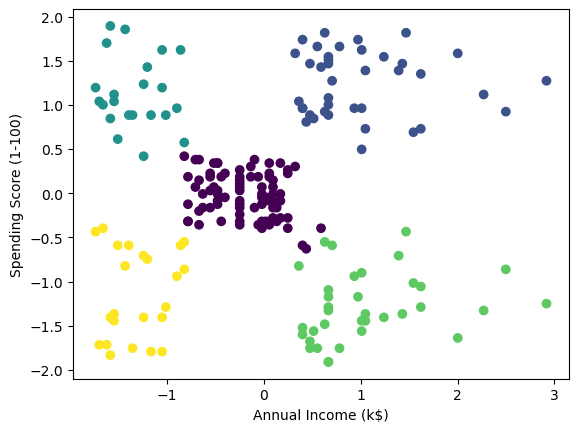

In [45]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=cluster)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [51]:
df[df['cluster']==0].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
43,44,Female,31,39,61,0
46,47,Female,50,40,55,0
47,48,Female,27,40,47,0
48,49,Female,29,40,42,0
49,50,Female,31,40,42,0
50,51,Female,49,42,52,0
51,52,Male,33,42,60,0
52,53,Female,31,43,54,0
53,54,Male,59,43,60,0
54,55,Female,50,43,45,0


In [53]:
df[df['cluster']==1].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
123,124,Male,39,69,91,1
125,126,Female,31,70,77,1
127,128,Male,40,71,95,1
129,130,Male,38,71,75,1
131,132,Male,39,71,75,1
133,134,Female,31,72,71,1
135,136,Female,29,73,88,1
137,138,Male,32,73,73,1
139,140,Female,35,74,72,1
141,142,Male,32,75,93,1


In [55]:
df[df['cluster']==3].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
124,125,Female,23,70,29,3
128,129,Male,59,71,11,3
130,131,Male,47,71,9,3
134,135,Male,20,73,5,3
136,137,Female,44,73,7,3
138,139,Male,19,74,10,3
140,141,Female,57,75,5,3
144,145,Male,25,77,12,3
146,147,Male,48,77,36,3
148,149,Female,34,78,22,3


In [57]:
df[df['cluster']==2].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
1,2,Male,21,15,81,2
3,4,Female,23,16,77,2
5,6,Female,22,17,76,2
7,8,Female,23,18,94,2
9,10,Female,30,19,72,2
11,12,Female,35,19,99,2
13,14,Female,24,20,77,2
15,16,Male,22,20,79,2
17,18,Male,20,21,66,2
19,20,Female,35,23,98,2


In [59]:
df[df['cluster']==4].head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
2,3,Female,20,16,6,4
4,5,Female,31,17,40,4
6,7,Female,35,18,6,4
8,9,Male,64,19,3,4
10,11,Male,67,19,14,4
12,13,Female,58,20,15,4
14,15,Male,37,20,13,4
16,17,Female,35,21,35,4
18,19,Male,52,23,29,4


## Иерархическая кластеризация 

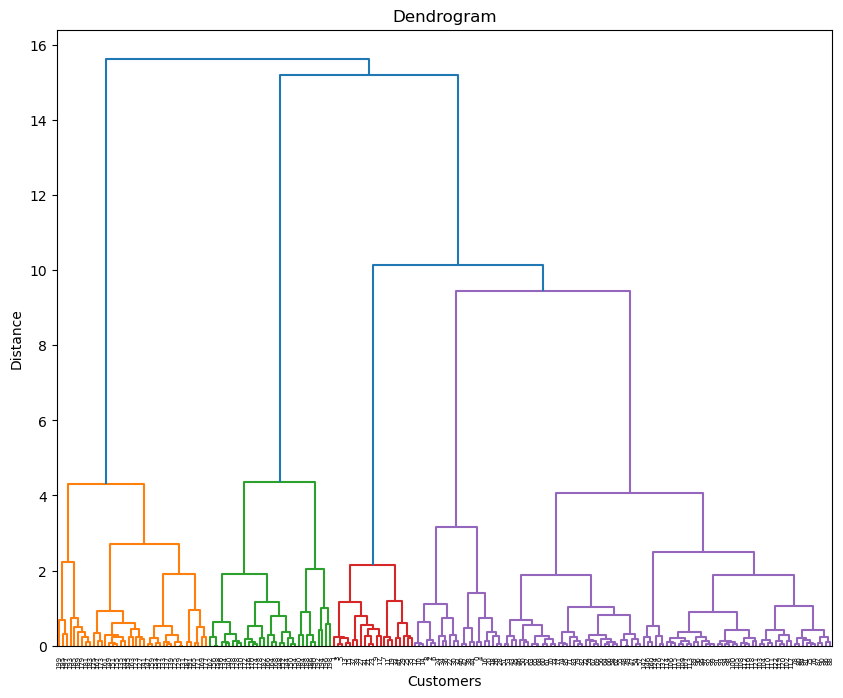

In [75]:
plt.figure(1, figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method="ward"), color_threshold=10)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [81]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
y_hc = hc.fit_predict(X_scaled)
y_hc

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int64)

In [83]:
df['customer_segment'] = pd.DataFrame(y_hc)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,customer_segment
0,1,Male,19,15,39,4,0
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,0


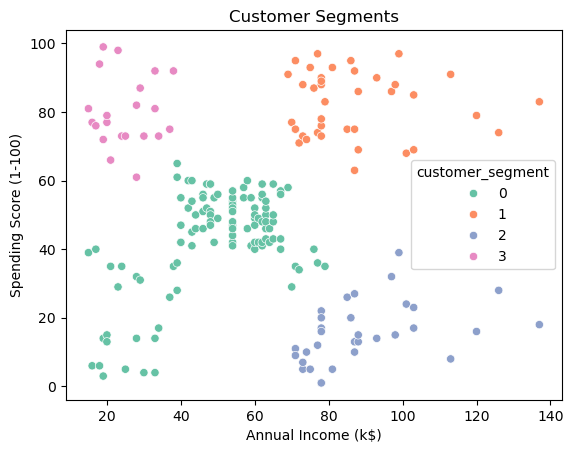

In [91]:
sns.scatterplot(data=df, x = "Annual Income (k$)",
                y="Spending Score (1-100)", 
                hue="customer_segment", 
                palette = "Set2")
plt.title("Customer Segments")
plt.show()

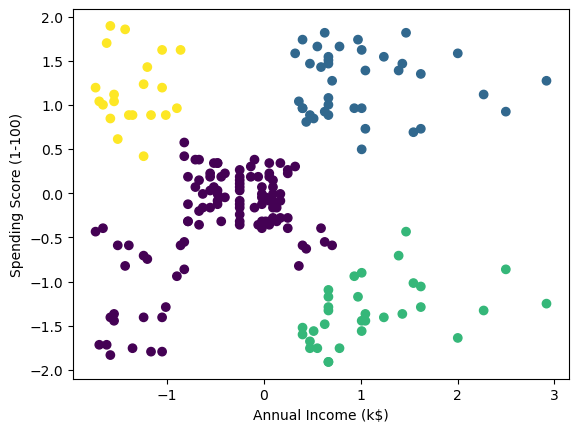

In [93]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=y_hc)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [95]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_scaled)
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int64)

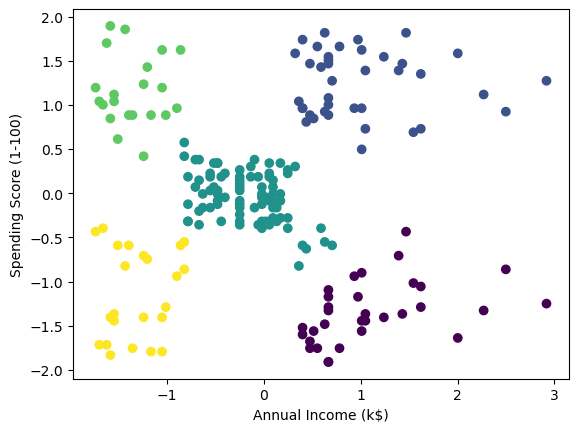

In [97]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=y_hc)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [99]:
sil=silhouette_score(X_scaled,y_hc)
db=davies_bouldin_score(X_scaled,y_hc)
ch=calinski_harabasz_score(X_scaled,y_hc)

print("\nSilhouette Score:",sil)
print("Davies-Bouldin Score:",db)
print("Calinski-Harabasz Score:",ch)


Silhouette Score: 0.5538089226688662
Davies-Bouldin Score: 0.5778621190740154
Calinski-Harabasz Score: 244.41032586596822


## DBSCAN

In [101]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

In [103]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,customer_segment,DBSCAN_Cluster
0,1,Male,19,15,39,4,0,2
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,0,1
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,0,2


In [105]:
dbscan_labels

array([ 2,  0,  1,  0,  2,  0,  1, -1,  1,  0, -1, -1, -1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0, -1, -1,  2, -1,  2, -1, -1,  0, -1, -1,
       -1, -1, -1,  0, -1,  0,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  4,  3,  4,  3,  4,  5,  4,  5,  4,  3,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  6,  4,  6,  4,  6, -1,
        6,  4,  6,  4,  6,  4,  6,  4,  6,  4, -1,  4,  6,  4, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=int64)

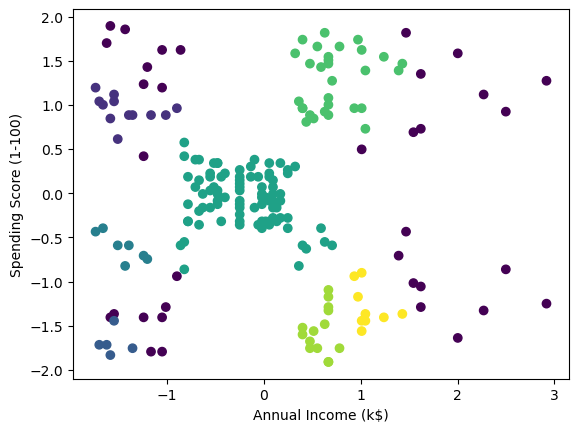

In [107]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=dbscan_labels)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

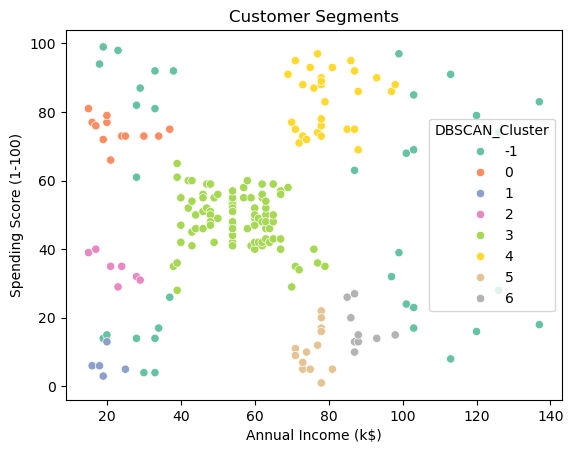

In [109]:
sns.scatterplot(data=df, x = "Annual Income (k$)",
                y="Spending Score (1-100)", 
                hue="DBSCAN_Cluster", 
                palette = "Set2")
plt.title("Customer Segments")
plt.show()

In [111]:
sil=silhouette_score(X_scaled,dbscan_labels)
db=davies_bouldin_score(X_scaled,dbscan_labels)
ch=calinski_harabasz_score(X_scaled,dbscan_labels)

print("\nSilhouette Score:",sil)
print("Davies-Bouldin Score:",db)
print("Calinski-Harabasz Score:",ch)


Silhouette Score: 0.31614121976731185
Davies-Bouldin Score: 2.0250698034375643
Calinski-Harabasz Score: 32.656415388075644


In [125]:
dbscan = DBSCAN(eps=0.3, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster2"] = dbscan_labels

In [127]:
sil=silhouette_score(X_scaled,dbscan_labels)
db=davies_bouldin_score(X_scaled,dbscan_labels)
ch=calinski_harabasz_score(X_scaled,dbscan_labels)

print("\nSilhouette Score:",sil)
print("Davies-Bouldin Score:",db)
print("Calinski-Harabasz Score:",ch)


Silhouette Score: 0.4136187833583574
Davies-Bouldin Score: 0.8505678492501992
Calinski-Harabasz Score: 105.09849320946482


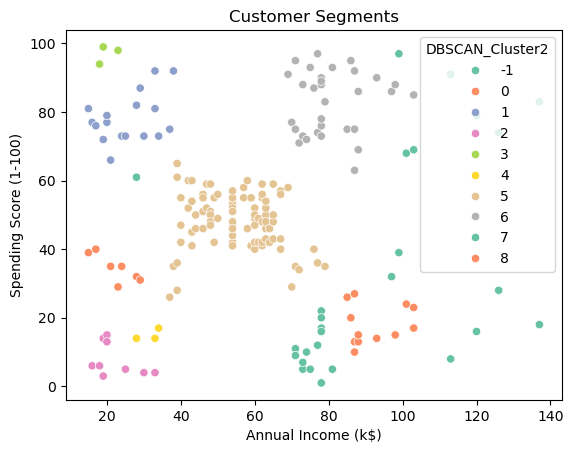

In [129]:
sns.scatterplot(data=df, x = "Annual Income (k$)",
                y="Spending Score (1-100)", 
                hue="DBSCAN_Cluster2", 
                palette = "Set2")
plt.title("Customer Segments")
plt.show()